# **RIDGE regression – TEST**

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from DataFramePrep import generate_TestDataFrame

# Metrics to measure successfulness
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler

# ML Stuff
from sklearn.linear_model import Ridge


In [ ]:
# Pre-processed data preparation
TrainingDataFrame, tickers, historic_columns, StockDataDatabase = generate_TestDataFrame()

In [ ]:
# To track how well predictions work, all metrics -> dominance, MAPE/APE and benchmark performance
performance_tracker = {}
performance_simple = {}
model_dominance = {}

for ticker in tickers["Ticker"]:
    # Bounded training-validation set
    Stock_Data = pd.read_sql(f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2025-09-18'", con=StockDataDatabase, parse_dates=["Date"])
    
    Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, left_on="Date", right_on="Date")

    Stock_Data["Target"] = Stock_Data["Close"]
    Stock_Data = Stock_Data.dropna().reset_index(drop=True)

    training_length = 4 # Days
    prediction_length = 1 # Days

    performance_tracker[ticker] = []
    performance_simple[ticker] = []
    model_dominance[ticker] = []

    MAPEs = []
    AccuracyToSimple = []
    dominance_dates = []
    for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
        if window_start + training_length + prediction_length > len(TrainingDataFrame):
            continue
            
        scaler = StandardScaler()

        Training_Features = scaler.fit_transform(TrainingDataFrame[historic_columns].iloc[window_start:window_start+training_length])
        Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]
    
        Test_Features = scaler.transform(TrainingDataFrame[historic_columns].iloc[window_start+training_length:window_start+training_length+prediction_length])
        Test_Target = Stock_Data["Target"].iloc[window_start+training_length:window_start+training_length+prediction_length]

        MODEL = Ridge(alpha=120)

        MODEL.fit(Training_Features, Training_Target)
    
        prediction = MODEL.predict(Test_Features)
        
        AccuracyToSimple.append(mean_absolute_percentage_error(Test_Target, prediction) <= (mean_absolute_percentage_error(Test_Target, [Training_Target.iloc[-1]])))
        MAPEs.append(100*mean_absolute_percentage_error(Test_Target, prediction))
        
        if mean_absolute_percentage_error(Test_Target, prediction) <= mean_absolute_percentage_error(Test_Target, [Training_Target.iloc[-1]]):
            dominance_dates.append(str(Stock_Data["Date"].iloc[window_start+training_length+prediction_length].date()))                                                        

        print(ticker, 100*mean_absolute_percentage_error(Test_Target, prediction))    
    
    performance_simple[ticker] = AccuracyToSimple.copy()
    performance_tracker[ticker] = MAPEs.copy()
    model_dominance[ticker] = dominance_dates.copy()

ACN 1.5323994438723418
ACN 2.891867150290079
ACN 3.3355788532244635
ACN 2.419900978466994
ACN 0.06680088797991027
ACN 0.03853527220042876
ACN 0.8224125931302305
ACN 0.1877147447761716
ACN 1.0577219095607897
ACN 1.2718289673092344
ACN 1.0017240272758665
ACN 0.15597961945325153
ACN 4.390695801147867
ACN 0.1593324531417699
ACN 0.16469618994754423
ACN 0.6623540053034421
ACN 3.34020306157653
ACN 0.8296744519054411
ACN 2.6633544376519978
ACN 4.684150362341206
ACN 0.23364947956965457
ACN 0.08733881589889282
ACN 1.469427643252291
ACN 1.170973897759844
ACN 1.001865975872995
ACN 2.268783452898925
ACN 0.7060209421063044
ACN 0.19701726136936154
ACN 0.6357214987927401
ACN 2.136185603648803
ACN 2.052684099608909
ACN 3.190755197876423
ACN 2.3826348894925564
ACN 1.1955033281364447
ACN 0.08663763851749492
ACN 1.2940494209179974
ACN 0.5867659674852562
ACN 0.7484400590811049
ACN 1.7994491850531467
ACN 0.9820286425623573
ACN 0.003965454298040328
ACN 0.35339171262007973
ACN 4.276500538627404
ACN 2.72656256

In [5]:
means_prevalences = [np.mean(i) for i in performance_simple.values()]
np.mean(means_prevalences)
# 0.444066099148723

np.float64(0.4588120740019474)

In [6]:
performance_tracker = pd.DataFrame(performance_tracker).astype("float")

# MEANS & RANGE Metrics
mean_performances = {}
range_performances = {}
for ticker in tickers["Ticker"]:
    mean_performances[ticker] = np.mean(performance_tracker[ticker])
    range_performances[ticker] = np.max(performance_tracker[ticker]) - np.min(performance_tracker[ticker])

mean_performances = dict(sorted(mean_performances.items(), key=lambda x: x[1]))
range_performances = dict(sorted(range_performances.items(), key=lambda x: x[1]))

In [7]:
np.mean(list(mean_performances.values()))

np.float64(1.7985240375404126)

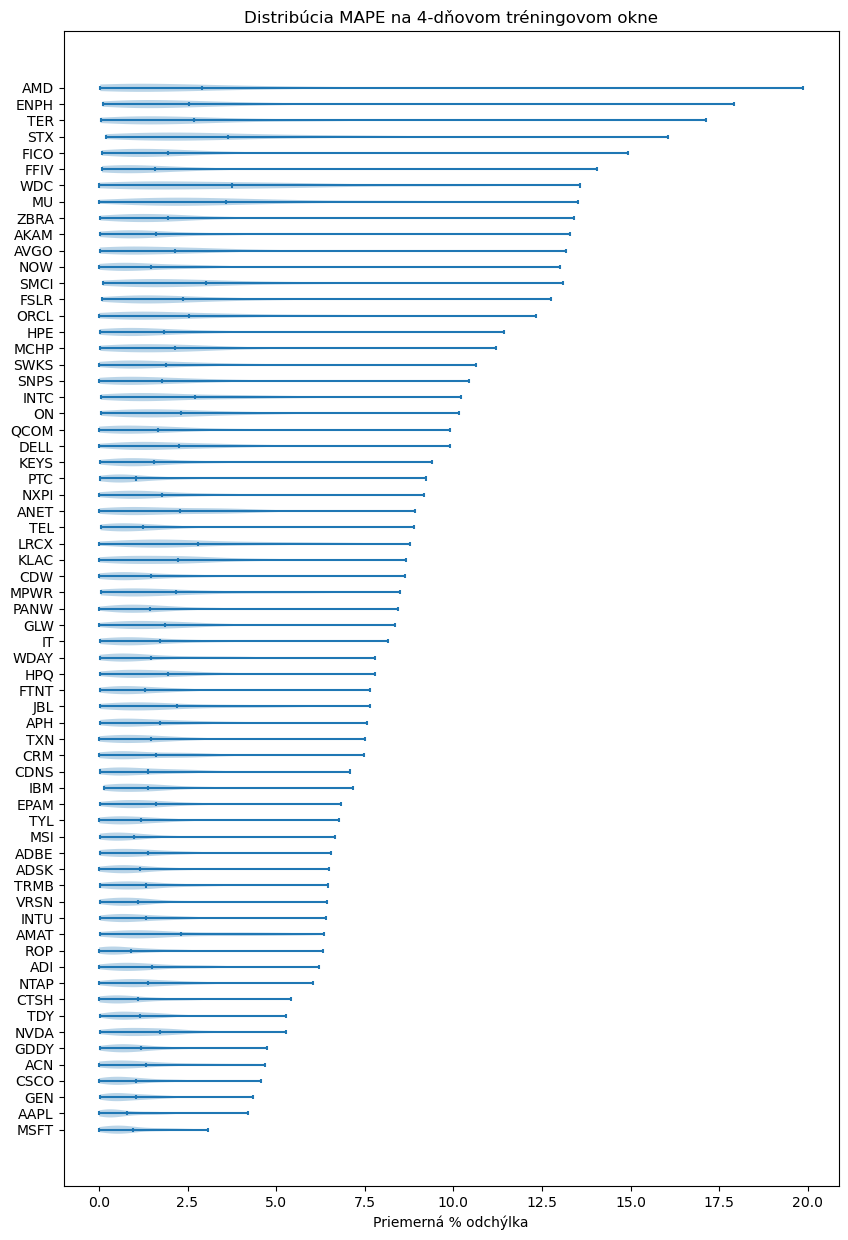

In [8]:
plt.figure(figsize=(10, 15))
plt.violinplot(performance_tracker[list(range_performances.keys())], showmeans=True, orientation="horizontal")

plt.xlabel("Priemerná % odchýlka")
plt.yticks(range(1, 66), list(range_performances.keys()))

plt.title(f"Distribúcia MAPE na {training_length}-dňovom tréningovom okne")

plt.show()

Here we include mean deviation results for single stocks' tickers.

In [9]:
mean_performances

{'AAPL': np.float64(0.7942744852368712),
 'ROP': np.float64(0.914416196057104),
 'MSFT': np.float64(0.9520011442476051),
 'MSI': np.float64(0.9804898655441115),
 'CSCO': np.float64(1.0363952813122228),
 'GEN': np.float64(1.043141805244495),
 'PTC': np.float64(1.0450366903146113),
 'VRSN': np.float64(1.098655697577542),
 'CTSH': np.float64(1.1158867828855794),
 'TDY': np.float64(1.1450988145240018),
 'ADSK': np.float64(1.162080052733669),
 'TYL': np.float64(1.1762432472133109),
 'GDDY': np.float64(1.195999424222488),
 'TEL': np.float64(1.2403845309532933),
 'FTNT': np.float64(1.2858452955446216),
 'TRMB': np.float64(1.3265368092195393),
 'INTU': np.float64(1.3308711725310838),
 'ACN': np.float64(1.338376088748292),
 'ADBE': np.float64(1.3714076573599345),
 'CDNS': np.float64(1.378327057018057),
 'NTAP': np.float64(1.3829096925597464),
 'IBM': np.float64(1.3847414090869947),
 'PANW': np.float64(1.4352343568302222),
 'NOW': np.float64(1.4611609950700108),
 'WDAY': np.float64(1.47104551184

# **RIDGE Stock-wise optimality**

In [16]:
optimal_parameters = {}
with open("RIDGE/RIDGE_StockWise.txt") as file:
    for i in file.readlines():
        data = i.split()
        optimal_parameters[data[0]] = int(data[1])

In [17]:
performance_tracker = {}
performance_simple = {}
model_dominance = {}

for ticker in tickers["Ticker"]:
    Stock_Data = pd.read_sql(f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2025-09-18'", con=StockDataDatabase, parse_dates=["Date"])
    
    Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, left_on="Date", right_on="Date")

    Stock_Data["Target"] = Stock_Data["Close"]
    Stock_Data = Stock_Data.dropna().reset_index(drop=True)

    training_length = 4 # Days
    prediction_length = 1 # Days

    performance_tracker[ticker] = []
    performance_simple[ticker] = []
    model_dominance[ticker] = []

    MAPEs = []
    AccuracyToSimple = []
    dominance_dates = []
    for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
        if window_start + training_length + prediction_length > len(TrainingDataFrame):
            continue
            
        scaler = StandardScaler()

        Training_Features = scaler.fit_transform(TrainingDataFrame[historic_columns].iloc[window_start:window_start+training_length])
        Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]
    
        Test_Features = scaler.transform(TrainingDataFrame[historic_columns].iloc[window_start+training_length:window_start+training_length+prediction_length])
        Test_Target = Stock_Data["Target"].iloc[window_start+training_length:window_start+training_length+prediction_length]

        MODEL = Ridge(alpha=optimal_parameters[ticker])

        MODEL.fit(Training_Features, Training_Target)
    
        prediction = MODEL.predict(Test_Features)
        
        AccuracyToSimple.append(mean_absolute_percentage_error(Test_Target, prediction) <= (mean_absolute_percentage_error(Test_Target, [Training_Target.iloc[-1]])))
        MAPEs.append(100*mean_absolute_percentage_error(Test_Target, prediction))
        
        if mean_absolute_percentage_error(Test_Target, prediction) <= mean_absolute_percentage_error(Test_Target, [Training_Target.iloc[-1]]):
            dominance_dates.append(str(Stock_Data["Date"].iloc[window_start+training_length+prediction_length].date()))                                                        

        print(ticker, 100*mean_absolute_percentage_error(Test_Target, prediction))    
    
    performance_simple[ticker] = AccuracyToSimple.copy()
    performance_tracker[ticker] = MAPEs.copy()
    model_dominance[ticker] = dominance_dates.copy()

ACN 1.4466692267776793
ACN 2.8309901213396826
ACN 3.144260794905054
ACN 2.602533337086173
ACN 0.18229702941025286
ACN 0.04802996220863476
ACN 0.7835587529283221
ACN 0.2061745771021246
ACN 1.0713559529398589
ACN 1.3404859363114372
ACN 1.069796414893967
ACN 0.19148061011385564
ACN 4.3941723967741835
ACN 0.009480712709934851
ACN 0.13708671286962085
ACN 0.7657010496808037
ACN 3.344836213857822
ACN 0.7603130881524434
ACN 2.601492401865716
ACN 4.659948810644455
ACN 0.07379230068328009
ACN 0.013326085364568982
ACN 1.404942862297646
ACN 1.1354285471177386
ACN 1.047692129897492
ACN 2.2087502574490405
ACN 0.616556984158028
ACN 0.14389998312280305
ACN 0.6467939585183647
ACN 2.169463020865732
ACN 1.9339349618527568
ACN 3.0675122711673994
ACN 2.2064298834659892
ACN 1.0477240271892394
ACN 0.18619235219804792
ACN 1.2980386862275197
ACN 0.6317582189233065
ACN 0.7265806398771167
ACN 1.8109090565336785
ACN 1.041809482775567
ACN 0.04602005618666357
ACN 0.3450895079236774
ACN 4.284865205512258
ACN 2.58263

In [18]:
means_prevalences = [np.mean(i) for i in performance_simple.values()]
np.mean(means_prevalences)
# 0.44650052001078544

np.float64(0.459396299902629)

In [19]:
performance_tracker = pd.DataFrame(performance_tracker).astype("float")

# MEANS & RANGE Metrics
mean_performances = {}
range_performances = {}
for ticker in tickers["Ticker"]:
    mean_performances[ticker] = np.mean(performance_tracker[ticker])
    range_performances[ticker] = np.max(performance_tracker[ticker]) - np.min(performance_tracker[ticker])

mean_performances = dict(sorted(mean_performances.items(), key=lambda x: x[1]))
range_performances = dict(sorted(range_performances.items(), key=lambda x: x[1]))

In [20]:
np.mean(list(mean_performances.values()))

np.float64(1.794449645476672)

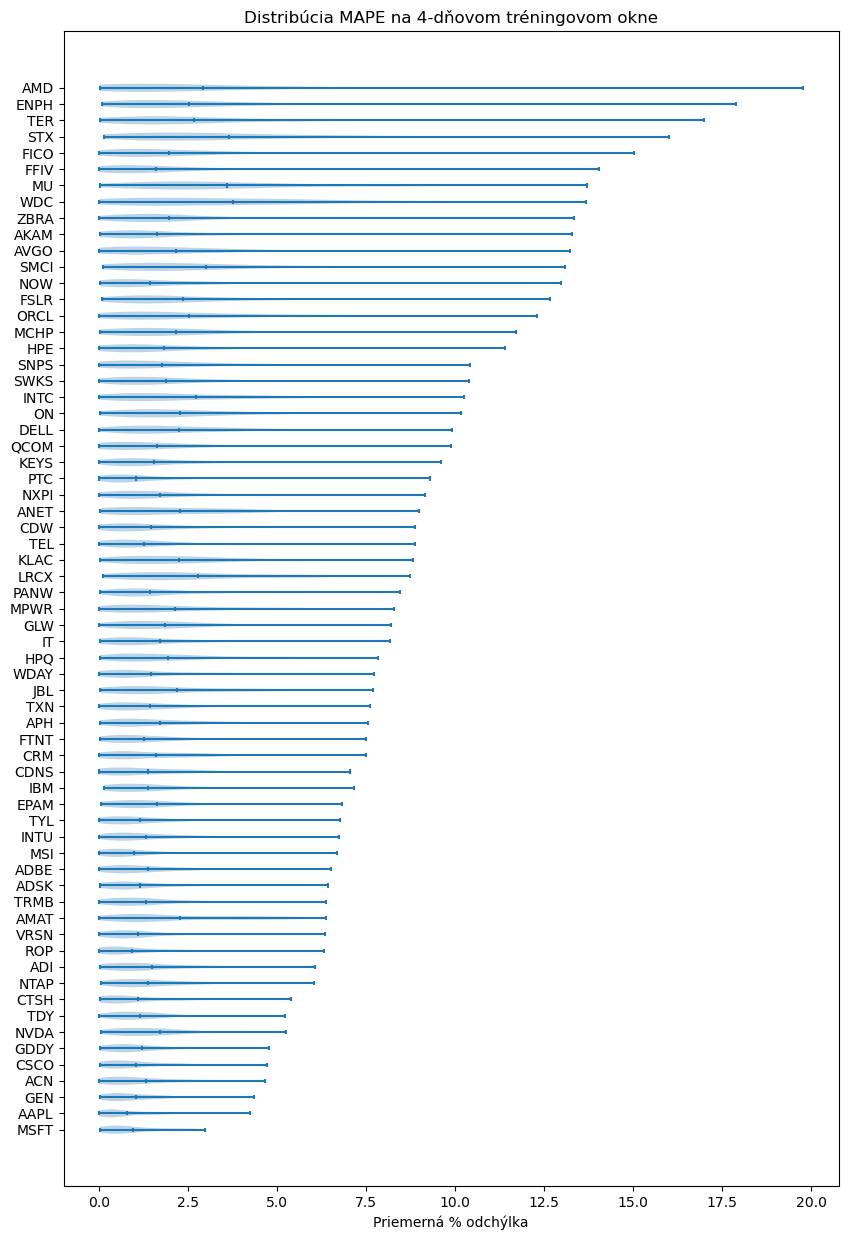

In [22]:
plt.figure(figsize=(10, 15))
plt.violinplot(performance_tracker[list(range_performances.keys())], showmeans=True, orientation="horizontal")

plt.xlabel("Priemerná % odchýlka")
plt.yticks(range(1, 66), list(range_performances.keys()))

plt.title(f"Distribúcia MAPE na {training_length}-dňovom tréningovom okne")

plt.show()

In [23]:
mean_performances

{'AAPL': np.float64(0.8000975293251498),
 'ROP': np.float64(0.9237568917743196),
 'MSFT': np.float64(0.9671868350408679),
 'MSI': np.float64(0.98815212015013),
 'CSCO': np.float64(1.0279711607211703),
 'PTC': np.float64(1.0363428500821652),
 'GEN': np.float64(1.0418144965696226),
 'VRSN': np.float64(1.0889358474688855),
 'CTSH': np.float64(1.1077070406292662),
 'ADSK': np.float64(1.153195114511931),
 'TYL': np.float64(1.1545399133226424),
 'TDY': np.float64(1.1589171844791166),
 'GDDY': np.float64(1.1974237346169516),
 'TEL': np.float64(1.2532719423207346),
 'FTNT': np.float64(1.2667111965362423),
 'ACN': np.float64(1.3191071894199964),
 'TRMB': np.float64(1.3221518152140521),
 'INTU': np.float64(1.335526294788228),
 'ADBE': np.float64(1.370245969472547),
 'CDNS': np.float64(1.3710197308165395),
 'NTAP': np.float64(1.3805435323763584),
 'IBM': np.float64(1.3878130982766896),
 'PANW': np.float64(1.432241555341982),
 'TXN': np.float64(1.4373047789654194),
 'NOW': np.float64(1.44730221738